# 01 — Problem and exploratory analysis

StudyPilot plans a study week from a student's habits and subject marks. The modelling question is: which study habits are associated with the exam score in the Kaggle **Student Performance Factors** table, and which simple model is honest enough to drive that plan?

The table is synthetic (6,607 rows). It is useful for checking a pipeline. It is not evidence about real students.

Figures below are regenerated from `data/StudentPerformanceFactors.csv` when you run this notebook, and the same views are stored in `reports/figures/`.


In [1]:
from pathlib import Path
from IPython.display import Image, display
import pandas as pd
from src.train import load_dataset

frame = load_dataset(Path("data/StudentPerformanceFactors.csv"))
print(f"{len(frame)} rows, {frame.shape[1]} columns")
print(frame["Exam_Score"].describe().round(3).to_string())
print("Missing cells:", int(frame.isna().sum().sum()))


6607 rows, 20 columns
count    6607.000
mean       67.236
std         3.890
min        55.000
25%        65.000
50%        67.000
75%        69.000
max       101.000
Missing cells: 235


reports/figures/eda_target.png


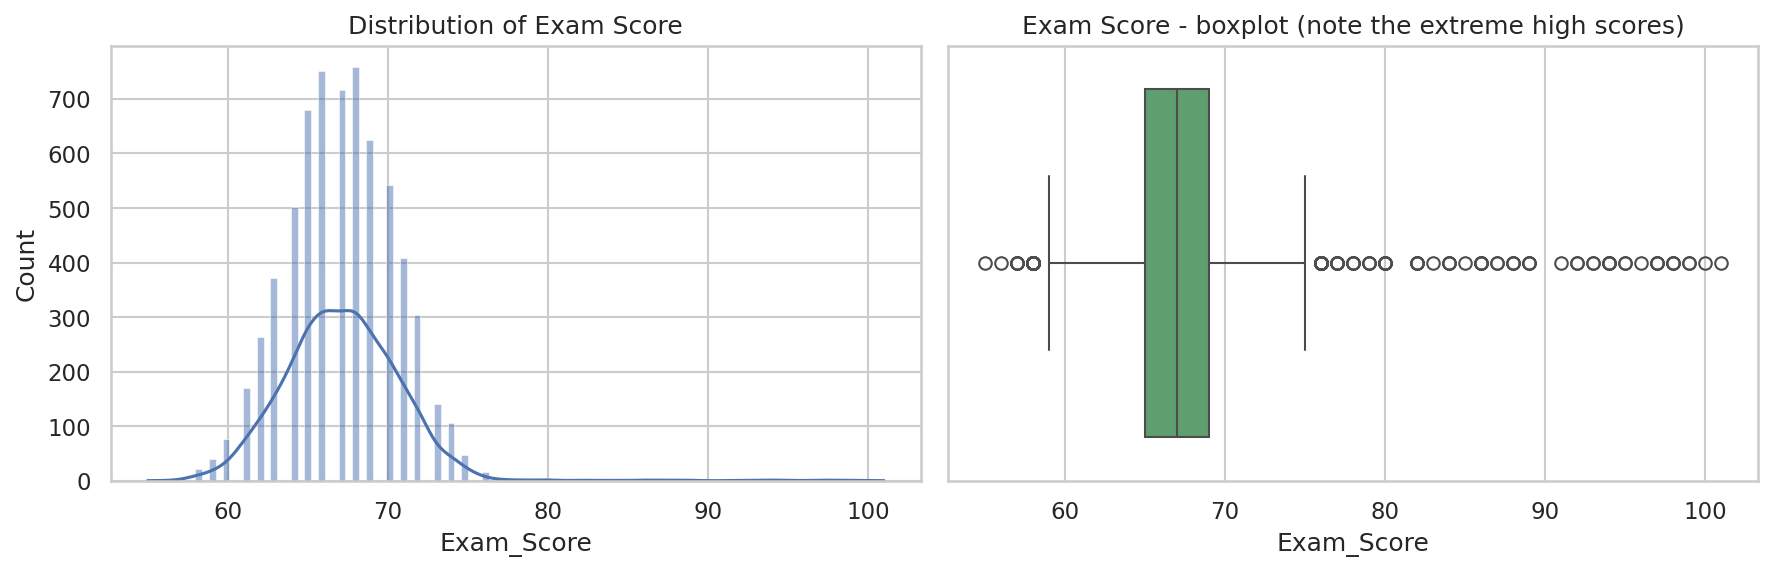

reports/figures/eda_scatter.png


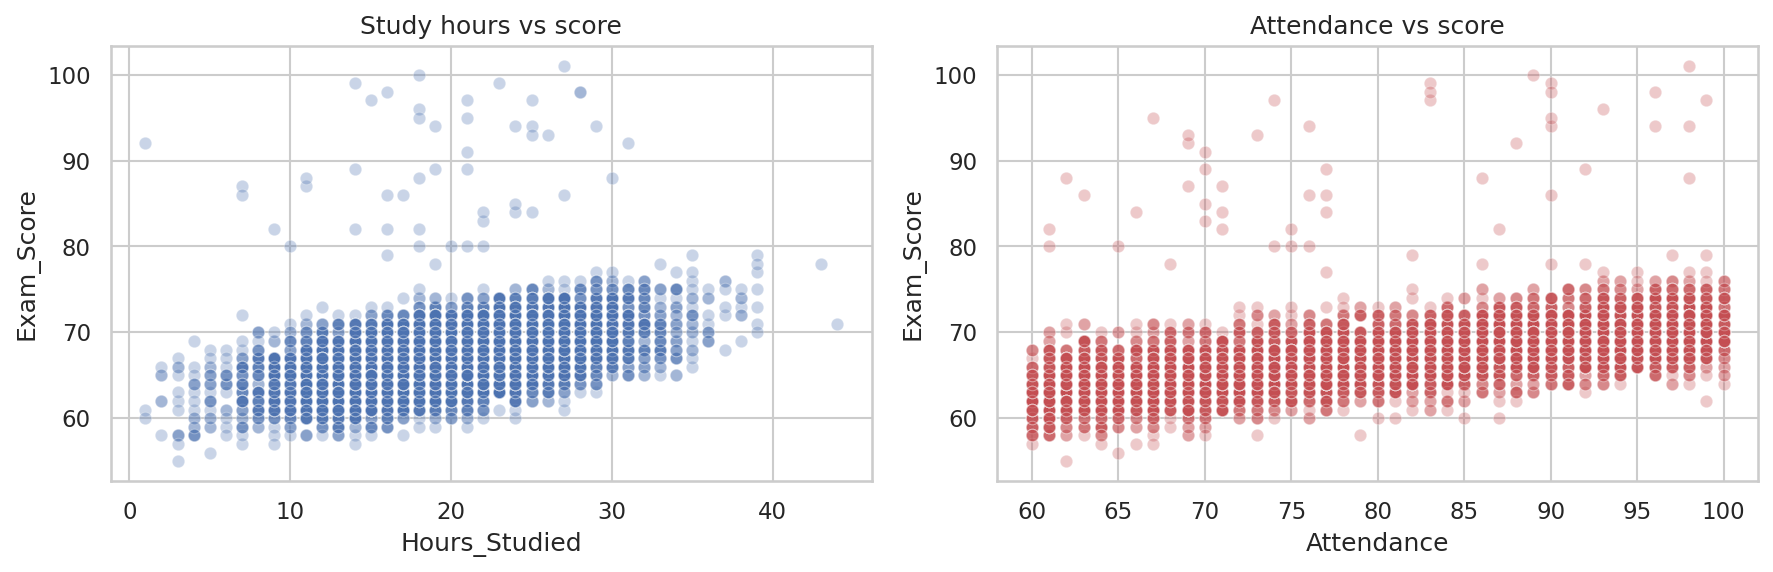

reports/figures/eda_correlation.png


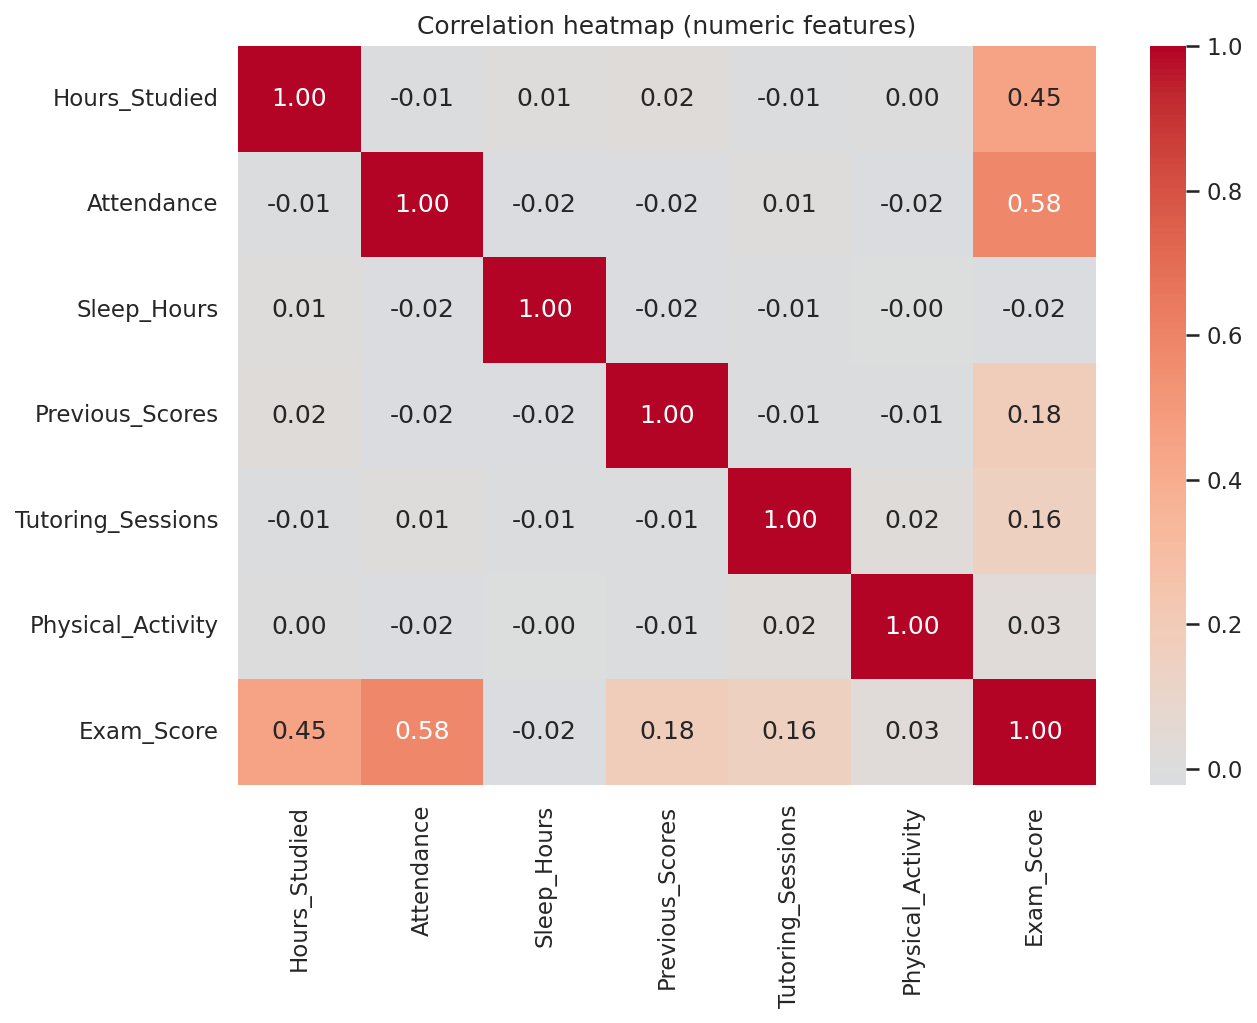

reports/figures/eda_categorical.png


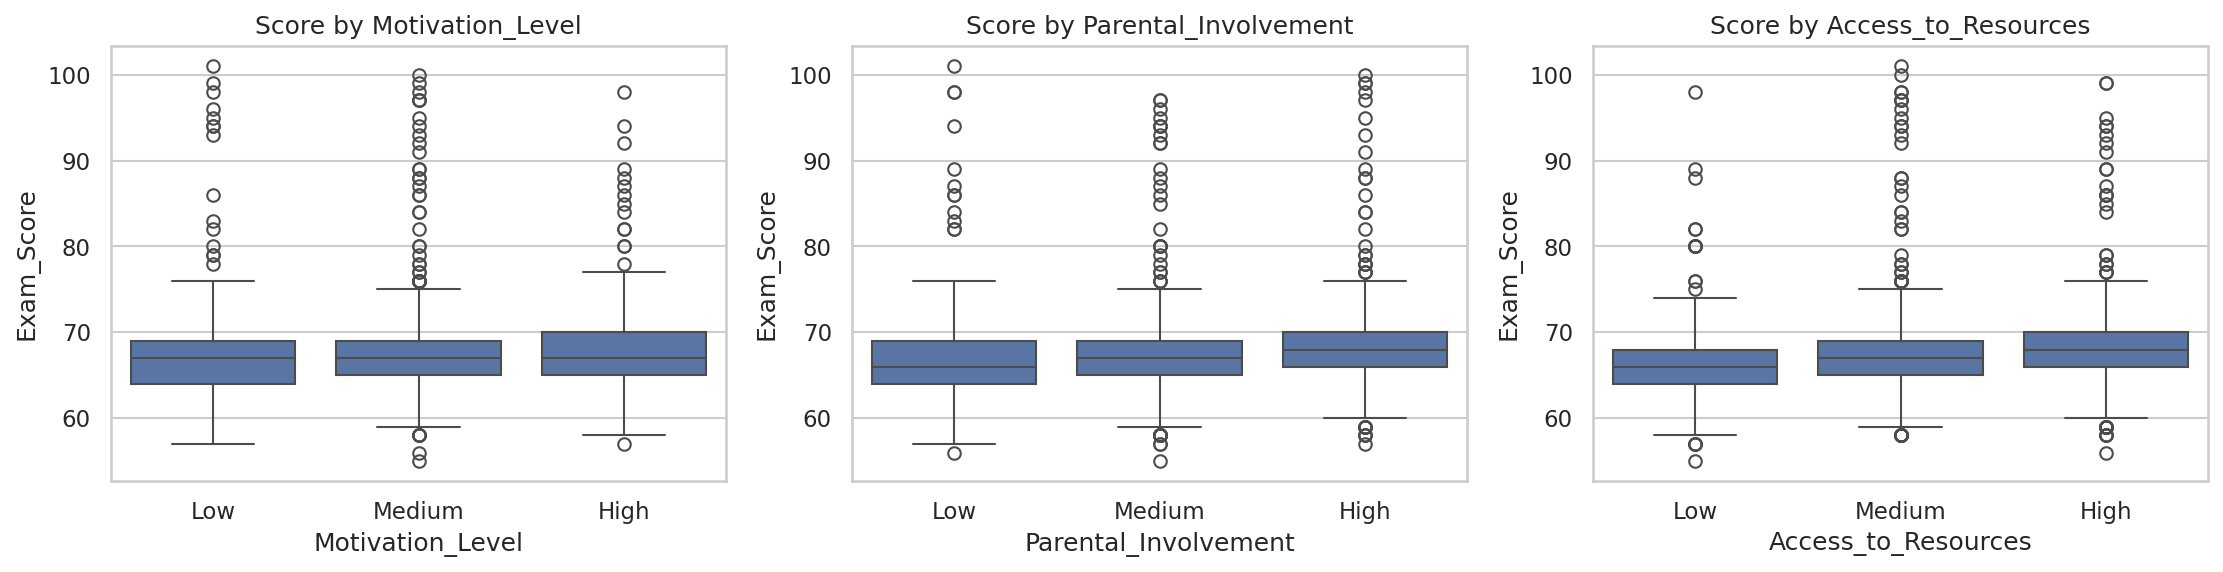

In [2]:
from pathlib import Path
from IPython.display import Image, display

# The saved report figures are the ones linked from the README.
for name in ["eda_target.png", "eda_scatter.png", "eda_correlation.png", "eda_categorical.png"]:
    path = Path("reports/figures") / name
    print(path.as_posix())
    display(Image(filename=str(path)))


## Insights

The describe() cell is the score distribution. Hours and attendance move with the score. A handful of very high scores sit far from that band; the model card says 11 of them in the original test split dominate squared error. Sensitive columns (gender, income, parental education, learning disabilities, school type, distance) are not used as model inputs.
